In [ ]:
# imports
import pandas as pd
import numpy as np
from tqdm import tqdm
import torch
import torch.nn as nn
import torch.optim as optim
from transformers import BertTokenizer, BertModel
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import train_test_split

In [ ]:
# load dataset
url = "https://docs.google.com/spreadsheets/d/1sfsZhhP2umXXtmEP_NRErxLuwgN98TyH7LWOq3j07O0/export?format=csv&gid=971821388"
df = pd.read_csv(url)
print(df.head())

    ID  Last Changed            Author  \
0  400           NaN     Carolyn Wells   
1  401           NaN     Carolyn Wells   
2  402           NaN     Carolyn Wells   
3  403           NaN  CHARLES KINGSLEY   
4  404           NaN  Charles Kingsley   

                                               Title  \
0                                    Patty's Suitors   
1                      Two Little Women on a Holiday   
2                                      Patty Blossom   
3     THE WATER-BABIES\nA Fairy Tale for a Land-Baby   
4  HOW THE ARGONAUTS WERE DRIVEN INTO THE UNKNOWN...   

                                           Anthology  \
0                                                NaN   
1                                                NaN   
2                                                NaN   
3                                                NaN   
4  The Heroes\n       or Greek Fairy Tales for my...   

                                                 URL     Source  Pub Year

In [ ]:
# keep relevant columns
df = df[['Excerpt', 'BT Easiness', 'Flesch-Reading-Ease', 'Flesch-Kincaid-Grade-Level']]
df = df.dropna()
print(df.head())

                                             Excerpt  BT Easiness  \
0  When the young people returned to the ballroom...    -0.340259   
1  All through dinner time, Mrs. Fayre was somewh...    -0.315372   
2  As Roger had predicted, the snow departed as q...    -0.580118   
3  Mr. Grimes was to come up next morning to Sir ...    -1.785965   
4  And outside before the palace a great garden w...    -1.054013   

   Flesch-Reading-Ease  Flesch-Kincaid-Grade-Level  
0                81.70                        5.95  
1                80.26                        4.86  
2                79.04                        6.03  
3                44.77                       20.51  
4                68.07                       12.06  


In [ ]:
# get BERT embeddings

tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')
model = BertModel.from_pretrained('bert-base-uncased')

def get_embedding(text):
  inputs = tokenizer(text, return_tensors = "pt", truncation = True,
                     padding = True, max_length = 512)
  with torch.no_grad():
    outputs = model(**inputs)
  return outputs.last_hidden_state.mean(dim = 1).squeeze().cpu().numpy()

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [ ]:
# feature matrix
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

def get_embeddings_optimized(text_list, batch_size = 8):
    model.to(device)
    model.eval()
    all_embeddings = []

    for i in tqdm(range(0, len(text_list), batch_size)):
        batch_texts = text_list[i : i + batch_size]

        # all excerpts in the batch are the same size
        inputs = tokenizer(batch_texts, return_tensors = "pt", truncation = True,
                           padding = True, max_length = 512).to(device)

        with torch.no_grad():
            outputs = model(**inputs)
            # average the word vectors to get 1 vector per excerpt
            embeddings = outputs.last_hidden_state[:, 0, :].cpu().numpy()
            all_embeddings.append(embeddings)

    return np.vstack(all_embeddings)

X = get_embeddings_optimized(df['Excerpt'].tolist(), batch_size = 8)

100%|██████████| 591/591 [01:10<00:00,  8.35it/s]


In [ ]:
# ml training split
from sklearn.model_selection import train_test_split

y = df['BT Easiness']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)

In [ ]:
# linear regression baseline
linear_model = LinearRegression()

linear_model.fit(X_train, y_train)

linear_pred = linear_model.predict(X_test)

print("\nLINEAR REGRESSION")
print("MSE:", mean_squared_error(y_test, linear_pred))
print("R2:", r2_score(y_test, linear_pred))


LINEAR REGRESSION
MSE: 0.4087051291658216
R2: 0.6414204939864518


In [ ]:
# ridge regression
ridge_model = Ridge(alpha=1.0)

ridge_model.fit(X_train, y_train)

ridge_pred = ridge_model.predict(X_test)

print("\nRIDGE REGRESSION")
print("MSE:", mean_squared_error(y_test, ridge_pred))
print("R2:", r2_score(y_test, ridge_pred))


RIDGE REGRESSION
MSE: 0.40128457403287027
R2: 0.6479309554513003


In [ ]:
# random forest
rf_model = RandomForestRegressor(
    n_estimators = 100,
    random_state = 42,
    n_jobs = -1
)

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

print("\nRANDOM FOREST")
print("MSE:", mean_squared_error(y_test, rf_pred))
print("R2:", r2_score(y_test, rf_pred))


RANDOM FOREST
MSE: 0.472825407380611
R2: 0.5851642445612533


In [ ]:
#xgb model

xgb_model = XGBRegressor(
    n_estimators = 200,
    learning_rate = 0.05,
    max_depth = 6,
    random_state = 42
)

xgb_model.fit(X_train, y_train)

xgb_pred = xgb_model.predict(X_test)

print("\nXGBOOST")
print("MSE:", mean_squared_error(y_test, xgb_pred))
print("R2:", r2_score(y_test, xgb_pred))


XGBOOST
MSE: 0.41995773213573945
R2: 0.6315479660283243


In [ ]:
# neural network

# convert numpy arrays to tensors
X_train_tensor = torch.tensor(X_train, dtype = torch.float32).to(device)
X_test_tensor = torch.tensor(X_test, dtype = torch.float32).to(device)

y_train_tensor = torch.tensor(
    y_train.values,
    dtype = torch.float32
).view(-1, 1).to(device)

# neural network model
class ReadabilityNN(nn.Module):

    def __init__(self, input_dim):

        super(ReadabilityNN, self).__init__()

        self.network = nn.Sequential(

            nn.Linear(input_dim, 256),
            nn.ReLU(),

            nn.Dropout(0.2),

            nn.Linear(256, 128),
            nn.ReLU(),

            nn.Linear(128, 1)
        )

    def forward(self, x):

        return self.network(x)

# initialize model
input_dim = X_train.shape[1]

nn_model = ReadabilityNN(input_dim).to(device)

criterion = nn.MSELoss()

optimizer = optim.Adam(
    nn_model.parameters(),
    lr=0.001
)

# train
epochs = 50

print("\nTRAINING NEURAL NETWORK")

loss_history = []
for epoch in range(epochs):

    nn_model.train()

    outputs = nn_model(X_train_tensor)

    loss = criterion(outputs, y_train_tensor)

    optimizer.zero_grad()

    loss.backward()

    optimizer.step()

    if (epoch + 1) % 10 == 0:

        print(f"Epoch {epoch+1}/{epochs}, Loss: {loss.item():.4f}")

    loss_history.append(loss.item())

# evaluate neural network
nn_model.eval()

with torch.no_grad():

    nn_predictions = nn_model(X_test_tensor)

    nn_predictions = nn_predictions.cpu().numpy().squeeze()

print("\nNEURAL NETWORK")
print("MSE:", mean_squared_error(y_test, nn_predictions))
print("R2:", r2_score(y_test, nn_predictions))


TRAINING NEURAL NETWORK
Epoch 10/50, Loss: 0.7341
Epoch 20/50, Loss: 0.4959
Epoch 30/50, Loss: 0.4464
Epoch 40/50, Loss: 0.4127
Epoch 50/50, Loss: 0.3900

NEURAL NETWORK
MSE: 0.395723537607821
R2: 0.6528099588009462


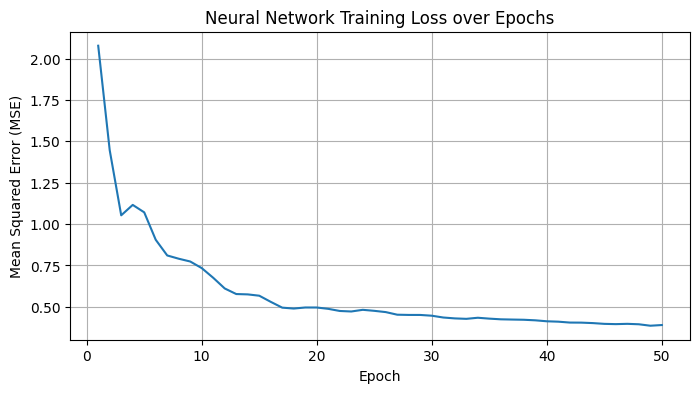

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 4))
plt.plot(range(1, epochs+1), loss_history)
plt.title("Neural Network Training Loss over Epochs")
plt.xlabel("Epoch")
plt.ylabel("Mean Squared Error (MSE)")
plt.grid(True)
plt.show()

In [ ]:
# compare against baseline
fkg_scores = df.loc[y_test.index, 'Flesch-Kincaid-Grade-Level']

print("\nFLESCH-KINCAID BASELINE")
print("MSE:", mean_squared_error(y_test, fkg_scores))
print("R2:", r2_score(y_test, fkg_scores))


FLESCH-KINCAID BASELINE
MSE: 130.04809064727317
R2: -113.0983481109785


In [ ]:
# save results
results = {

    "Model": [
        "Linear Regression",
        "Ridge Regression",
        "Random Forest",
        "XGBoost",
        "Neural Network",
        "Flesch-Kincaid Baseline"
    ],

    "MSE": [
        mean_squared_error(y_test, linear_pred),
        mean_squared_error(y_test, ridge_pred),
        mean_squared_error(y_test, rf_pred),
        mean_squared_error(y_test, xgb_pred),
        mean_squared_error(y_test, nn_predictions),
        mean_squared_error(y_test, fkg_scores)
    ],

    "R2": [
        r2_score(y_test, linear_pred),
        r2_score(y_test, ridge_pred),
        r2_score(y_test, rf_pred),
        r2_score(y_test, xgb_pred),
        r2_score(y_test, nn_predictions),
        r2_score(y_test, fkg_scores)
    ]
}

results_df = pd.DataFrame(results)

# sort by MSE (lower is better)
results_df = results_df.sort_values(by="MSE")

print("FINAL MODEL COMPARISON")
print(results_df)

# save results
results_df.to_csv("model_results.csv", index=False)

print("\nResults saved as model_results.csv")

FINAL MODEL COMPARISON
                     Model         MSE          R2
4           Neural Network    0.395724    0.652810
1         Ridge Regression    0.401285    0.647931
0        Linear Regression    0.408705    0.641420
3                  XGBoost    0.419958    0.631548
2            Random Forest    0.472825    0.585164
5  Flesch-Kincaid Baseline  130.048091 -113.098348

Results saved as model_results.csv


/tmp/ipykernel_834/3873267728.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


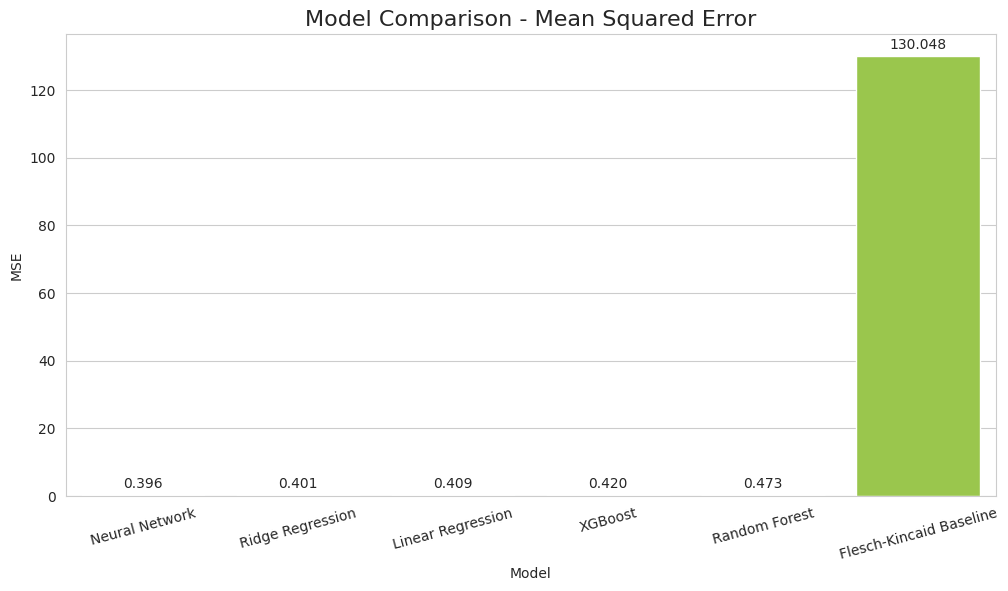

/tmp/ipykernel_834/3873267728.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


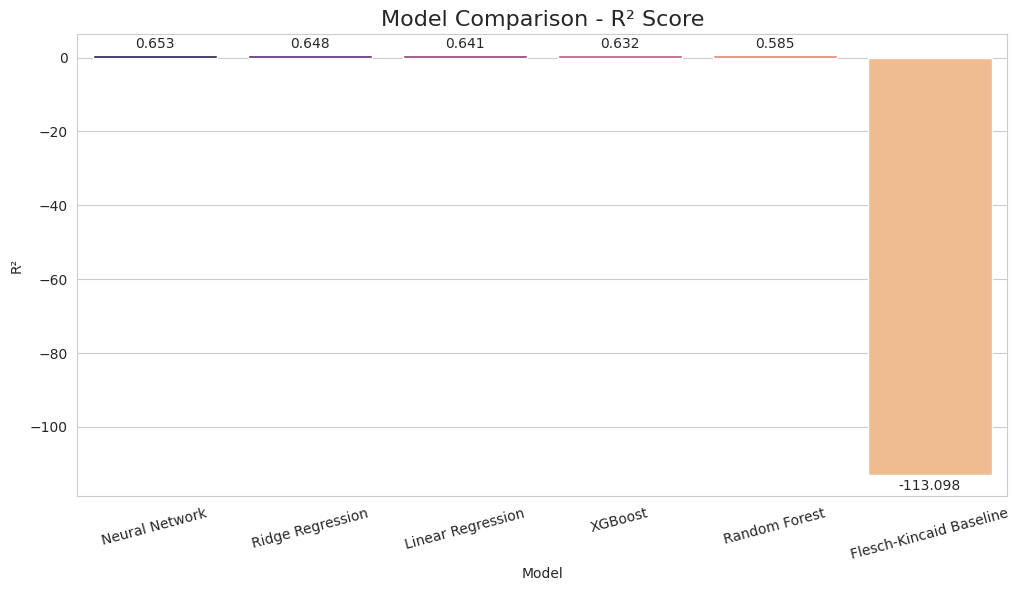

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# mse comparison
sns.set_style("whitegrid")

plt.figure(figsize=(12,6))

sns.barplot(
    data=results_df,
    x="Model",
    y="MSE",
    palette="viridis"
)
for container in plt.gca().containers:
    plt.gca().bar_label(container, fmt='%.3f', padding=3)

plt.title("Model Comparison - Mean Squared Error", fontsize=16)

plt.ylabel("MSE")
plt.xlabel("Model")

plt.xticks(rotation=15)

plt.show()

# r2 comparison
plt.figure(figsize=(12,6))

sns.barplot(
    data=results_df,
    x="Model",
    y="R2",
    palette="magma"
)
for container in plt.gca().containers:
    plt.gca().bar_label(container, fmt='%.3f', padding=3)

plt.title("Model Comparison - R² Score", fontsize=16)

plt.ylabel("R²")
plt.xlabel("Model")

plt.xticks(rotation=15)

plt.show()